In [2]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [4]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [5]:
import zipfile
import os

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

print("Files inside data folder:")
print(os.listdir("data"))

Files inside data folder:
['stocks.csv']


In [6]:
for root, dirs, files in os.walk("data"):
    for file in files:
        print(os.path.join(root, file))

data/stocks.csv


In [7]:
import pandas as pd

df = pd.read_csv("data/stocks.csv")
df.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2/7/2023,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2/8/2023,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2/9/2023,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2/10/2023,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2/13/2023,150.949997,154.259995,150.919998,153.850006,153.850006,62199000


In [8]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Ticker     248 non-null    object 
 1   Date       248 non-null    object 
 2   Open       248 non-null    float64
 3   High       248 non-null    float64
 4   Low        248 non-null    float64
 5   Close      248 non-null    float64
 6   Adj Close  248 non-null    float64
 7   Volume     248 non-null    int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 15.6+ KB


,0
Ticker,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


Preprocessing

In [10]:
# Convert 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

# Fill missing values
df.fillna(method='ffill', inplace=True)

# Use only numerical columns: Open, High, Low, Close, Volume
data = df[['Open', 'High', 'Low', 'Close', 'Volume']].values

# Scale the data to 0-1 range
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

/tmp/ipykernel_28433/3869954854.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Prepare Data for LSTM

In [11]:
sequence_length = 60  # use last 60 days to predict next day
X, y = [], []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i, 3])  # 'Close' price index

X, y = np.array(X), np.array(y)

# Split into training and testing sets (80%-20%)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

Build the LSTM Model

In [12]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))  # Predict the closing price

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,451 (122.86 KB)

 Trainable params: 31,451 (122.86 KB)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [13]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - loss: 0.1669 - val_loss: 0.1149
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.1213 - val_loss: 0.1045
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.1072 - val_loss: 0.1132
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.1114 - val_loss: 0.1025
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.1115 - val_loss: 0.1004
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.1078 - val_loss: 0.1011
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.1048 - val_loss: 0.1022
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.1083 - val_loss: 0.1006
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.1049 - val_loss: 0.0987
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.1096 - val_loss: 0.0984
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.1069 - val_loss: 0.1044
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.1050 - val_loss: 0.1036


Make Predictions

In [14]:
# Predict stock prices
predicted = model.predict(X_test)

# Inverse transform to original scale
predicted_prices = scaler.inverse_transform(
    np.concatenate((np.zeros((predicted.shape[0], 4)), predicted), axis=1)
)[:, -1]

actual_prices = scaler.inverse_transform(
    np.concatenate((np.zeros((y_test.shape[0], 4)), y_test.reshape(-1,1)), axis=1)
)[:, -1]

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 597ms/step


evaluate Model

Root Mean Squared Error: 35926735.063279994


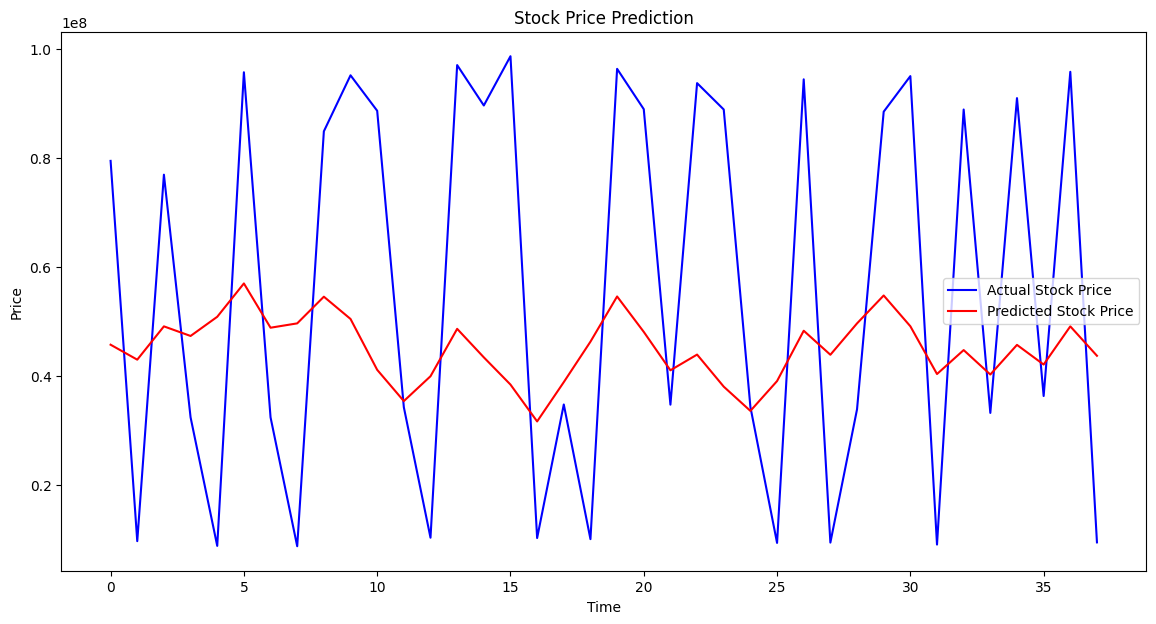

In [15]:
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
print(f"Root Mean Squared Error: {rmse}")

# Plot actual vs predicted
plt.figure(figsize=(14,7))
plt.plot(actual_prices, color='blue', label='Actual Stock Price')
plt.plot(predicted_prices, color='red', label='Predicted Stock Price')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [16]:
model.save("stock_price_lstm_model.h5")

Averages

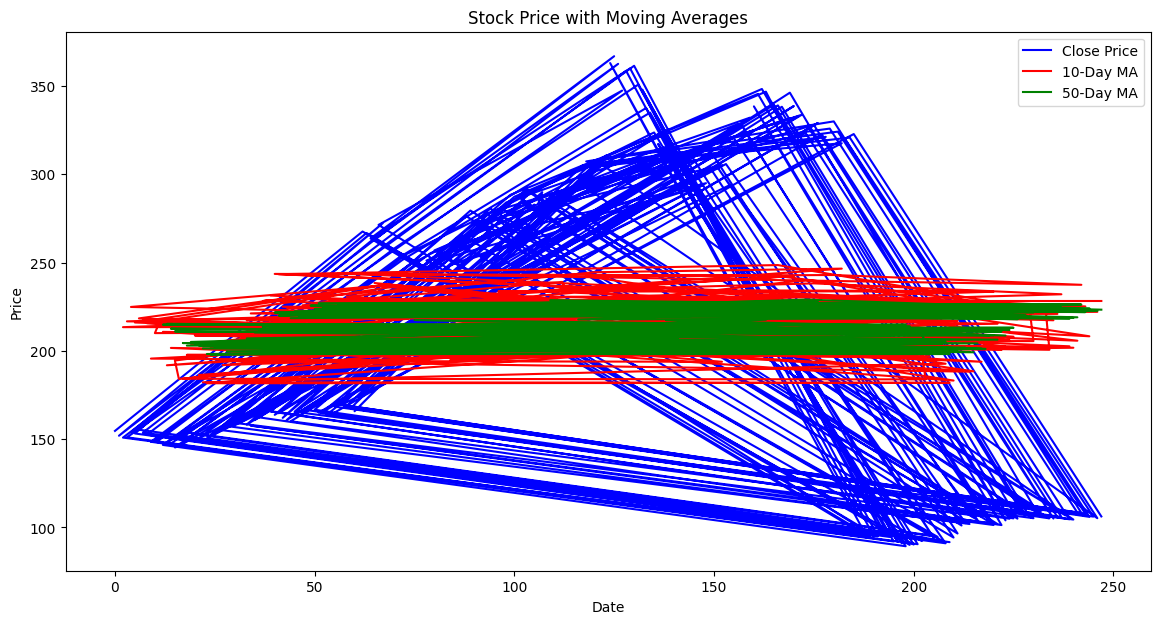

In [18]:
# Calculate moving averages
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

plt.figure(figsize=(14,7))
plt.plot(df['Close'], label='Close Price', color='blue')
plt.plot(df['MA10'], label='10-Day MA', color='red')
plt.plot(df['MA50'], label='50-Day MA', color='green')
plt.title('Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

Prediction VS Actual Line

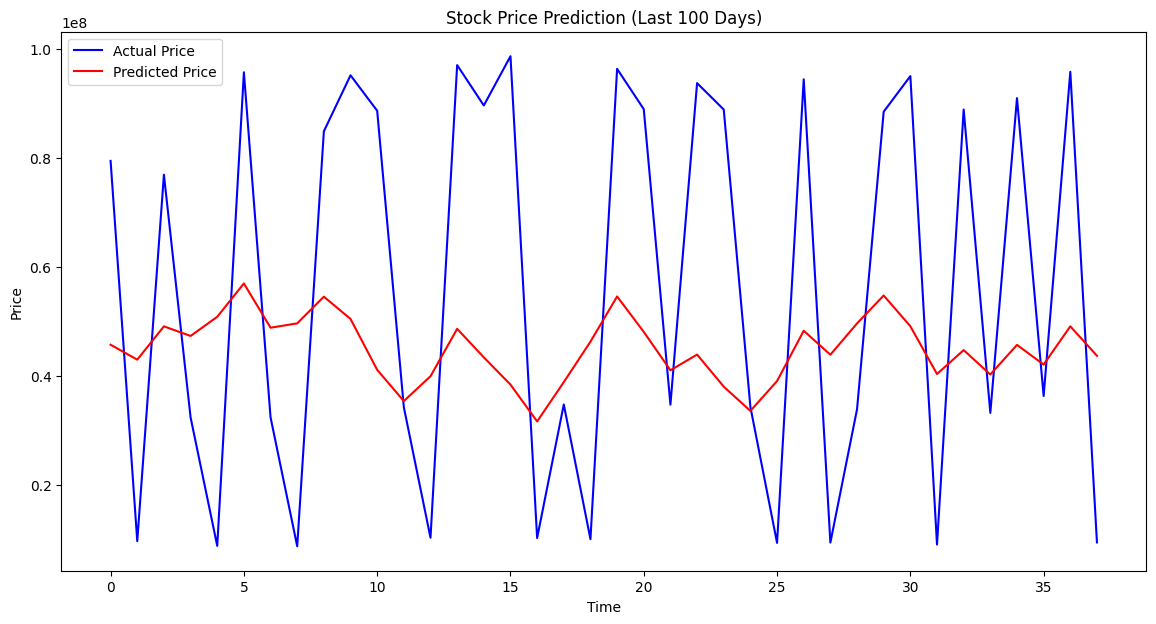

In [19]:
plt.figure(figsize=(14,7))
plt.plot(actual_prices[-100:], color='blue', label='Actual Price')
plt.plot(predicted_prices[-100:], color='red', label='Predicted Price')
plt.title('Stock Price Prediction (Last 100 Days)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

Error Visulization

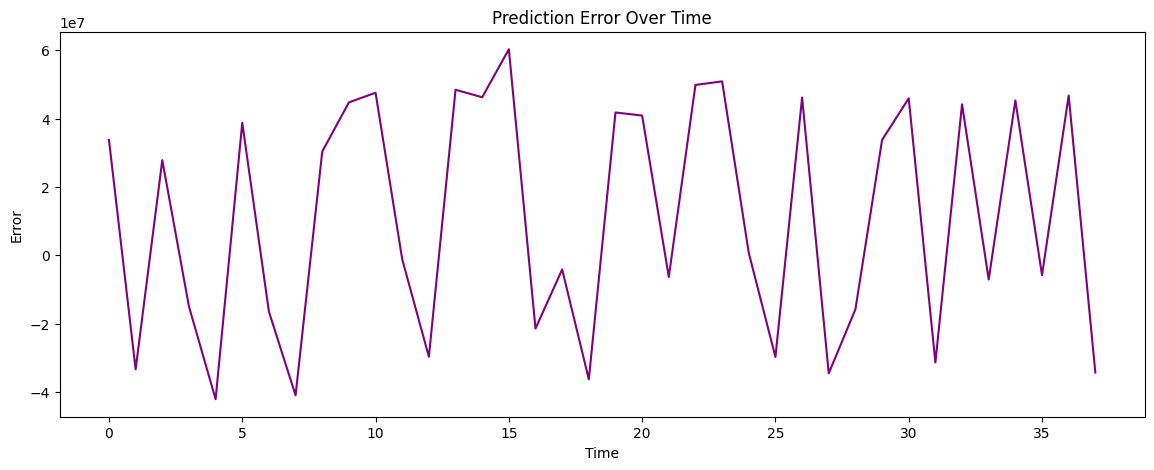

In [20]:
errors = actual_prices - predicted_prices
plt.figure(figsize=(14,5))
plt.plot(errors, color='purple')
plt.title('Prediction Error Over Time')
plt.xlabel('Time')
plt.ylabel('Error')
plt.show()

Corelation Heatmap

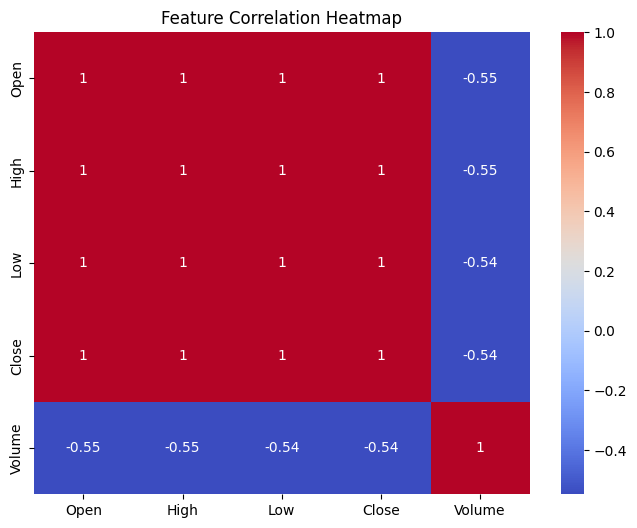

In [21]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df[['Open','High','Low','Close','Volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

Price vs Volume

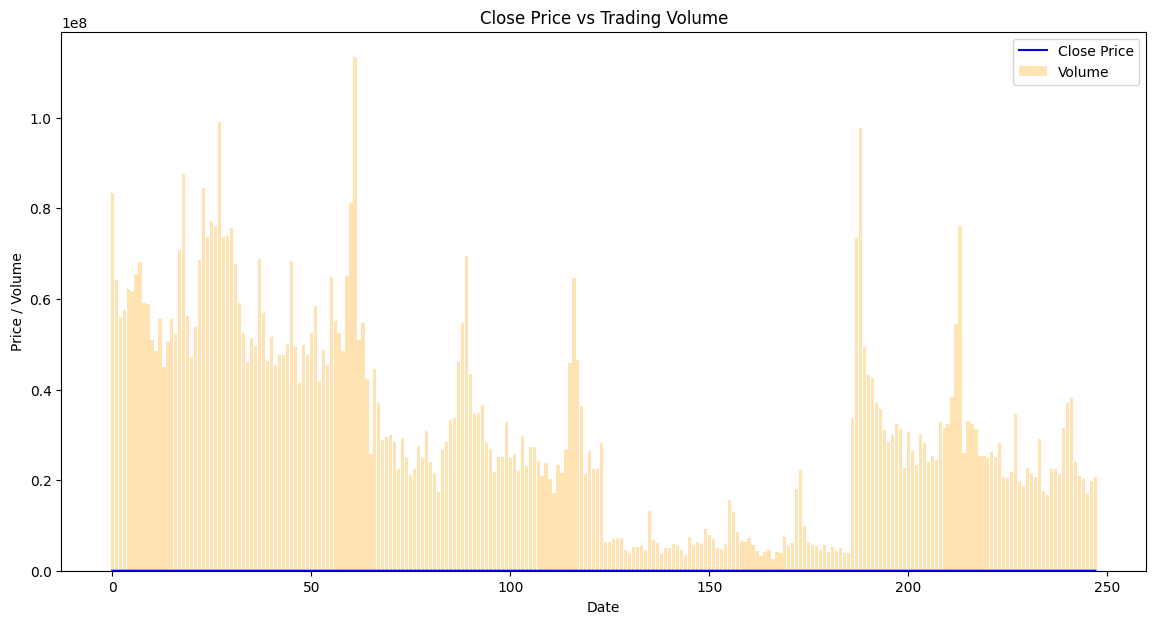

In [22]:
plt.figure(figsize=(14,7))
plt.plot(df['Close'], color='blue', label='Close Price')
plt.bar(df.index, df['Volume'], color='orange', alpha=0.3, label='Volume')
plt.title('Close Price vs Trading Volume')
plt.xlabel('Date')
plt.ylabel('Price / Volume')
plt.legend()
plt.show()

Rolling Volatility

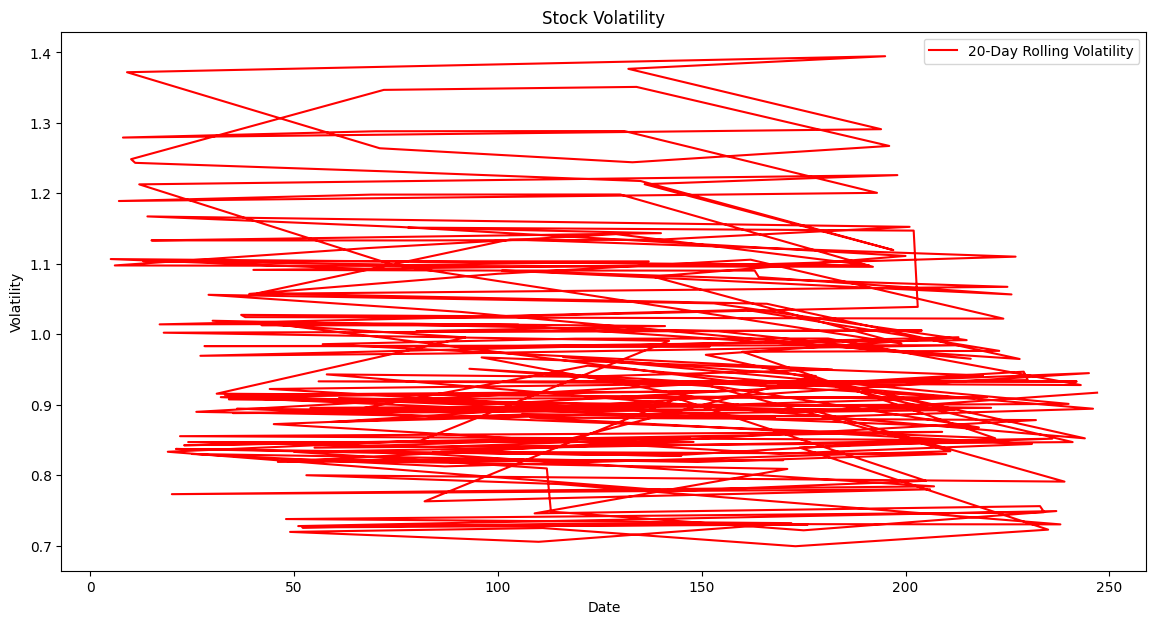

In [23]:
df['Returns'] = df['Close'].pct_change()
df['Volatility'] = df['Returns'].rolling(window=20).std()

plt.figure(figsize=(14,7))
plt.plot(df['Volatility'], color='red', label='20-Day Rolling Volatility')
plt.title('Stock Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.show()